# Example: Capital Allocation with Risky and Risk-Free Assets

In this example, we compute the maximum Sharpe ratio (tangent) portfolio for a user-chosen ticker subset, construct the Capital Allocation Line (CAL) from the risk-free rate through the tangent portfolio, and forward-simulate a blended allocation of risky and risk-free assets across synthetic futures generated by the hybrid [JumpHMM](https://github.com/varnerlab/JumpHMM.jl) construction.

> __Learning Objectives:__
>
> * __Tangent Portfolio:__ Compute the maximum Sharpe ratio portfolio using second-order cone programming and interpret its composition relative to the minimum-variance allocation. The tangent portfolio maximizes the risk-adjusted growth rate per unit of volatility.
> * __Capital Allocation Line:__ Construct the CAL from the risk-free rate and the tangent portfolio and explain why it dominates the risky-only efficient frontier. The CAL provides the best achievable risk-return trade-off when a risk-free asset is available.
> * __Forward Simulation:__ Evaluate synthetic out-of-sample performance of a CAL-blended portfolio against risk-free and market benchmarks. Comparing the blended allocation to passive alternatives reveals how the Sharpe advantage translates into terminal wealth.

Let's get started!
___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via the `Include.jl` file. This activates the local Julia environment and loads all dependencies.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Implementations
We define a few helper functions for this lab. See the comments for details. 

In [2]:
"""
    summary_row(name, final_wealth)

Helper function to compute summary statistics for a given portfolio's final wealth distribution. 
It returns a named tuple with the portfolio name, median final wealth, 5% Value at Risk (VaR), 
and Sharpe ratio relative to the initial capital `B₀`.
"""
function summary_row(name, final_wealth)
        med_w = median(final_wealth);
        var5  = quantile(final_wealth, 0.05);
        vol   = std(final_wealth);
        sr_val = vol > 0 ? (med_w - B₀) / vol : 0.0;
        return (Portfolio = name,
                Median_W = round(med_w, digits=0),
                VaR_5 = round(var5, digits=0),
                Sharpe = round(sr_val, digits=3));
end;

### Constants
In the section below, we set some constants that will be used throughout the notebook. These include the list of tickers to consider, the target return for the minimum-variance portfolio, and the number of forward-simulation paths to generate, etc. We can modify these constants to explore different scenarios and allocations. 

See the comments in the code for more details on each constant, it's purpose, units, etc.

In [3]:
# --- Portfolio universe ---
# Load the ticker universe from data/my-tickers.csv. To change the universe,
# edit that file directly (see lets_find_my_tickers.md for the procedure).
# Every ticker must exist in MySIMCalibration()["tickers"].
tickers_df = CSV.read(joinpath(_PATH_TO_DATA, "my-tickers.csv"), DataFrame);
my_tickers = String.(tickers_df.ticker);
N          = nrow(tickers_df);

# --- Portfolio configuration ---
# Load budget, risk-free rate, cash fraction, target growth, and concentration cap from portfolio-config.toml.
cfg            = TOML.parsefile(joinpath(_PATH_TO_DATA, "portfolio-config.toml"));
B₀             = Float64(cfg["portfolio"]["initial_budget"]);
g_f            = Float64(cfg["portfolio"]["risk_free_rate"]);
cash_fraction  = Float64(get(cfg["portfolio"], "cash_fraction", 0.10));                # fraction (1-θ) held in the risk-free asset
R_target       = Float64(cfg["portfolio"]["target_growth"]);                           # QP return constraint: μᵀ w ≥ R_target (1/yr, CCGR)
w_max          = Float64(get(cfg["portfolio"], "max_weight", 1.0));                    # per-ticker concentration cap enforced in QP bounds
@assert w_max >= 1.0/N "max_weight = $(w_max) is infeasible for N = $(N) tickers (need >= $(round(1/N, digits=3)))"

# --- Forward simulation parameters ---
n_paths  = 500;            # forward Monte Carlo paths
n_steps  = 252;            # trading days in the forward horizon
Δt       = 1.0 / 252.0;    # time step (years per trading day)

___
## Task 1: Compute the Efficient Frontier and Tangent Portfolio
In this task, are going to compute the efficient frontier and tangent portfolio for a user-chosen subset of tickers from the S&P 500 universe, using the single index model (SIM) parameters calibrated from 2014–2024 data. We'll then estimate the tangent portfolio.

> __What are we going to do?__
>
> Three passes take us from ticker list to tangent portfolio.
>
> * __Load:__ Pull the calibrated SIM parameters for `my_tickers` from [the `MySIMCalibration()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySIMCalibration), along with the configured risk-free rate.
> * __Build:__ Assemble the expected growth-rate vector $\mu$ and the SIM covariance matrix $\Sigma$ from those parameters.
> * __Sweep and select:__ Trace the long-only efficient frontier by solving a sequence of minimum-variance QPs, then take the frontier point with the highest Sharpe ratio as the tangent portfolio.
>
> The Sharpe ratio $(E[g_p] - g_f)/\sigma_p$ is evaluated against the configured risk-free rate $g_f$.

> __SIM Calibration:__
>
> [The `MySIMCalibration()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySIMCalibration) returns a `Dict` with $\alpha$, $\beta$, $\sigma_{\varepsilon}$, and $R^2$ for every ticker in the S&P 500 calibration universe, fitted from 2014–2024 VWAP data by regressing each ticker's annualized growth rate on SPY. All quantities are in **annualized growth-rate units** (1/year).

We store the single index model parameters in the `sim_estimates::Vector{MySIMParameterEstimate}` array, the `σ_m::Float64` market volatility scalar, and `sim_calibration::Dict{String, Any}` dictionary for easy parameter lookup by ticker. 

In [4]:
sim_estimates, σ_m, sim_calibration = let

    # --- Step 1: Load the SIM parameter estimates (saved by the SIM notebook) ---
    sim_data = load_results(joinpath(_PATH_TO_DATA, "sim-parameter-estimates.jld2"));
    all_estimates = sim_data["sim_estimates"];
    est_lookup = Dict{String, MySIMParameterEstimate}();
    for est ∈ all_estimates
        est_lookup[est.ticker] = est;
    end

    # --- Step 2: Validate that every user ticker is present ---
    missing = [t for t ∈ my_tickers if !haskey(est_lookup, t)];
    @assert isempty(missing) "Tickers not in SIM estimates: $(missing)"

    # --- Step 3: Extract the subset for our universe ---
    estimates = [est_lookup[t] for t ∈ my_tickers];

    # --- Step 4: Market volatility ---
    σm = sim_data["sigma_market"];

    # --- Step 5: Display the calibrated parameters for the subset ---
    df = DataFrame(
        "Ticker" => [e.ticker for e ∈ estimates],
        "α (%/yr)" => [round(e.α * 100, digits=2) for e ∈ estimates],
        "β" => [round(e.β, digits=3) for e ∈ estimates],
        "σ_ε grow (%/yr)" => [round(e.σ_ε * 100, digits=1) for e ∈ estimates],
        "σ_ε vol (%/yr)"  => [round(e.σ_ε / sqrt(252) * 100, digits=2) for e ∈ estimates],
        "R²" => [round(e.r², digits=3) for e ∈ estimates]
    );
    println("SIM parameters for $(length(estimates)) tickers:")
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
    println("Market σ_m (1/year): $(round(σm, digits=4))  "
            * "→ growth %/yr: $(round(σm*100, digits=1))%  "
            * "fin vol %/yr: $(round(σm/sqrt(252)*100, digits=2))%")

    estimates, σm, sim_data
end;

SIM parameters for 20 tickers:
 -------- ---------- --------- ----------------- ---------------- ---------
  Ticker   α (%/yr)         β   σ_ε grow (%/yr)   σ_ε vol (%/yr)        R² 
  String    Float64   Float64           Float64          Float64   Float64 
 -------- ---------- --------- ----------------- ---------------- ---------
      VZ      -6.51      0.45             281.8            17.75     0.199
       T     -10.58     0.629             339.8             21.4     0.251
     MCD       2.66      0.69             239.0            15.06     0.449
      PG        1.5     0.486             251.5            15.84     0.267
      KO      -2.74     0.626             242.5            15.28     0.394
     PEP      -0.22     0.543             269.1            16.95     0.285
     WMT       6.04     0.496             309.4            19.49       0.2
     XOM      -9.36     0.944             366.8            23.11     0.393
     CVX      -9.56     1.029             337.1            21.24 

The SIM expected growth-rate vector is $g_i = \alpha_i + \beta_i \cdot E[g_{\mathrm{mkt}}]$ where $E[g_{\mathrm{mkt}}]$ is pulled from [the `MySyntheticTrainingDataSet()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySyntheticTrainingDataSet). The cell below binds three values for downstream use: `E_g_mkt::Float64` (expected market growth rate, annualized, 1/yr), `g_vec::Vector{Float64}` (per-ticker SIM expected growth rates, 1/yr, one entry per ticker in `my_tickers` order), and `Σ::Matrix{Float64}` (SIM covariance matrix in 1/yr² units).

In [5]:
E_g_mkt, g_vec, Σ = let
    # --- Step 1: Expected market growth rate from the synthetic training dataset ---
    ds = MySyntheticTrainingDataSet();
    Egmkt = mean(ds["market_returns"]);      # 1/year

    # --- Step 2: SIM expected growth rate per ticker: μ_i = α_i + β_i · E[g_mkt] ---
    μ = [est.α + est.β * Egmkt for est ∈ sim_estimates];

    # --- Step 3: SIM covariance matrix ---
    Σ = build_sim_covariance(sim_estimates, σ_m);

    println("E[g_mkt] (annualized market growth rate): $(round(Egmkt*100, digits=2))%/yr");
    println("g range across user tickers: [$(round(minimum(μ)*100, digits=2)), $(round(maximum(μ)*100, digits=2))]%/yr");
    println("Σ condition number: $(round(cond(Σ), digits=1))");

    (Egmkt, μ, Σ)
end;

E[g_mkt] (annualized market growth rate): 7.93%/yr
g range across user tickers: [-5.59, 20.08]%/yr
Σ condition number: 65.9


We sweep the target return to trace the risky-only efficient frontier, evaluate the Sharpe ratio along that sampled frontier, and store both the frontier and the highest-Sharpe point.

> __Tangent Portfolio:__
>
> The tangent portfolio maximizes the Sharpe ratio $\text{SR} = (\mathbb{E}[g_p] - g_f) / \sigma_p$ subject to long-only constraints. In this notebook, we approximate it by sweeping the long-only efficient frontier over a grid of target returns, computing the Sharpe ratio at each frontier point, and selecting the point with the largest value.

Let's solve this problem and take a look at the results. The cell below binds:

* `minvar_result::MyPortfolioPerformanceResult` — the minimum-variance portfolio at the target return.
* `frontier_risk::Vector{Float64}` — efficient-frontier risk levels across the sweep.
* `frontier_return::Vector{Float64}` — efficient-frontier returns across the sweep.
* `sharpe_result::Dict{String,Any}` — tangent-portfolio summary (max-Sharpe allocation and associated metadata).

In [6]:
minvar_result, frontier_risk, frontier_return, sharpe_result = let

    # --- Step 1: Long-only bounds with overweight cap ---
    bounds = hcat(zeros(N), fill(w_max, N));

    # --- Step 2: Solve the minimum-variance QP at the target return from portfolio-config.toml ---
    problem = build(MyPortfolioAllocationProblem;
        μ = g_vec, Σ = Σ, bounds = bounds, R = R_target);
    mv = solve_minvariance(problem);

    # --- Step 3: Sweep the target return to trace the efficient frontier ---
    R_sweep = range(0.0, stop = maximum(g_vec) * 0.95, length = 200) |> collect;
    f_risk   = Float64[];
    f_return = Float64[];
    f_weights = Vector{Float64}[];
    for R ∈ R_sweep
        p = build(MyPortfolioAllocationProblem; μ = g_vec, Σ = Σ, bounds = bounds, R = R);
        sol = solve_minvariance(p);
        push!(f_risk, sqrt(sol.variance));
        push!(f_return, sol.expected_return);
        push!(f_weights, sol.weights);
    end

    # --- Step 4: Identify the tangent portfolio (max Sharpe on the frontier) ---
    frontier_sr = [(f_return[i] - g_f) / f_risk[i] for i ∈ eachindex(f_risk)];
    tang_idx    = argmax(frontier_sr);
    tang_vol    = f_risk[tang_idx];
    tang_ret    = f_return[tang_idx];
    tang_w      = f_weights[tang_idx];
    sr_ann      = frontier_sr[tang_idx];
    sr_trad     = sr_ann * sqrt(1/Δt);

    sr = Dict{String,Any}(
        "weights"         => tang_w,
        "sharpe_ratio"    => sr_ann,
        "expected_return" => tang_ret,
        "volatility"      => tang_vol,
        "status"          => "OPTIMAL",
    );

    mv_vol = sqrt(mv.variance);
    println("Min-var portfolio: E[g] = $(round(mv.expected_return*100, digits=2))%/yr, σ = $(round(mv_vol/sqrt(252)*100, digits=2))%/yr");
    println("Tangent portfolio: E[g] = $(round(tang_ret*100, digits=2))%/yr, σ = $(round(tang_vol/sqrt(252)*100, digits=2))%/yr");
    println("Sharpe ratio (annualized units): $(round(sr_ann, digits=4))");
    println("Sharpe ratio (traditional, per-Δt):  $(round(sr_trad, digits=4))");

    (mv, f_risk, f_return, sr)
end;


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Min-var portfolio: E[g] = 7.0%/yr, σ = 13.11%/yr
Tangent portfolio: E[g] = 13.61%/yr, σ = 18.89%/yr
Sharpe ratio (annualized units): 0.0304
Sharpe ratio (traditional, per-Δt):  0.4824


The tangent portfolio weights and the Sharpe ratio tell us which assets contribute most to risk-adjusted performance.

> __Sharpe Ratio Units:__
>
> Because our single index model parameters are in annualized growth-rate units (1/year), the Sharpe ratio from our solver is also in annualized units: $\text{SR}_{\text{ann}} = (E[g_p] - g_f) / \sigma_p$ where both the numerator and denominator are in 1/year. 
> 
> However, the **traditional** (per-timestep) Sharpe ratio used in practice scales by the square root of the (inverse) time step: $\sqrt{1/\Delta t} = \sqrt{252}$: Thus, $\text{SR}_{\text{trad}} = \text{SR}_{\text{ann}} \times \sqrt{252}$. We report both below for clarity.

We save the weights of the tangent portfolio in the `tangent_weights::Vector{Float64}` variable.

In [7]:
tangent_weights = let

    # initialize -
    w = sharpe_result["weights"]; # get the weights from the sharpe_result dictionary

    # some helper logic to round small weights to zero for cleaner display
    rnz(x, d) = begin
        r = round(x, digits=d);
        r == 0.0 ? 0.0 : r;
    end;

    # build a DataFrame to display the tangent portfolio allocation and SIM parameters
    df = DataFrame(
        "Ticker"     => my_tickers, # these are my tickers from the my_tickers variable (recommended)
        "Weight (%)" => rnz.(w .* 100, 2), # round the weights to 2 decimal places and convert to percentage
        "β"          => round.([est.β for est ∈ sim_estimates], digits=3),
        "α (%/yr)"   => round.([est.α for est ∈ sim_estimates] .* 100, digits=2),
    );

    # print out a table of the tangent portfolio allocation and SIM parameters
    println("Tangent portfolio allocation (Sharpe ratio = $(round(sharpe_result["sharpe_ratio"], digits=4)) and $(round(sharpe_result["sharpe_ratio"] * sqrt(1/Δt), digits=4))):");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    w; # return the raw weights vector for later use
end;

Tangent portfolio allocation (Sharpe ratio = 0.0304 and 0.4824):
 -------- ------------ --------- ----------
  Ticker   Weight (%)         β   α (%/yr) 
  String      Float64   Float64    Float64 
 -------- ------------ --------- ----------
      VZ          0.0      0.45      -6.51
       T          0.0     0.629     -10.58
     MCD         5.26      0.69       2.66
      PG          0.0     0.486        1.5
      KO          0.0     0.626      -2.74
     PEP          0.0     0.543      -0.22
     WMT         20.0     0.496       6.04
     XOM          0.0     0.944      -9.36
     CVX          0.0     1.029      -9.56
     JPM          0.0     1.203       0.06
   BRK.B        16.05     0.907       2.68
     JNJ          0.0     0.537       -1.6
     MRK          0.0     0.568       0.28
     HON          0.0      1.07      -3.02
     UPS          0.0     0.867      -7.44
    AAPL         20.0     1.211      10.47
    MSFT         20.0     1.147      10.03
     APD          0.0     0.

___

## Task 2: Construct and Visualize the Capital Allocation Line
In this task, we compute the Capital Allocation Line (CAL) and visualize it alongside the efficient frontier.

> __Capital Allocation Line (CAL):__
>
> Let $\theta \in [0, \infty)$ denote the fraction of wealth placed in the tangent (risky) portfolio, with the remaining $1 - \theta$ held in the risk-free asset (so `cash_fraction` $= 1 - \theta$). The CAL is the set of portfolios indexed by $\theta$: expected growth rate $\mathbb{E}[g_p] = (1-\theta)\, g_f + \theta\, \mathbb{E}[g_{\text{tangent}}]$ and volatility $\sigma_p = \theta\, \sigma_{\text{tangent}}$. 
> 
> Eliminating $\theta$ gives the usual form $\mathbb{E}[g_p] = g_f + \text{SR}_{\text{tangent}} \cdot \sigma_p$, where $\text{SR}_{\text{tangent}}$ is the tangent portfolio's Sharpe ratio. Values $\theta < 1$ lend at $g_f$, $\theta = 1$ is the pure tangent portfolio, and $\theta > 1$ borrow at $g_f$ to lever the risky holding.

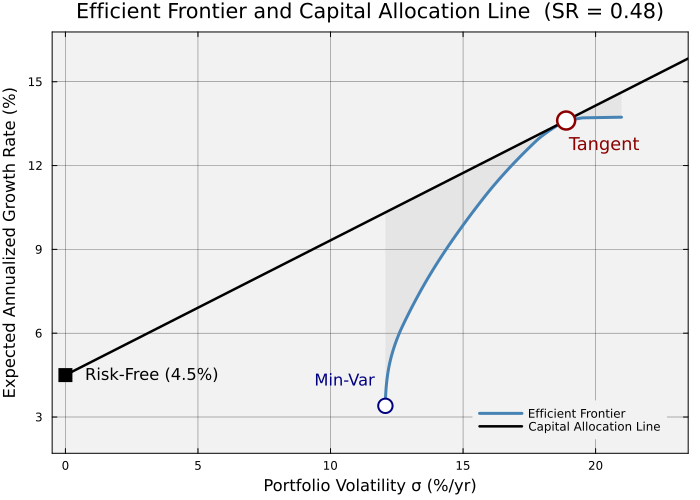

In [8]:
let
    # --- Extract key coordinates from Task 1 artifacts ---
    tang_ret = sharpe_result["expected_return"];
    tang_vol = sharpe_result["volatility"];
    sr_ann   = sharpe_result["sharpe_ratio"];

    mv_idx = argmin(frontier_risk);
    mv_vol = frontier_risk[mv_idx];
    mv_ret = frontier_return[mv_idx];

    # --- Convert to finance-convention %/yr: σ_finance = σ_growth / √252 ---
    scale      = 1.0 / sqrt(252);
    fr_pct     = frontier_risk  .* scale .* 100;   # frontier σ, %/yr
    fμ_pct     = frontier_return .* 100;           # frontier E[g], %/yr
    tang_vol_p = tang_vol * scale * 100;
    tang_ret_p = tang_ret * 100;
    mv_vol_p   = mv_vol   * scale * 100;
    mv_ret_p   = mv_ret   * 100;
    g_f_p      = g_f      * 100;

    # --- CAL in finance-vol units: E[g_p] = g_f + (SR_ann / scale) · σ_finance ---
    sg_finance = sr_ann / scale;                    # slope of CAL in finance units
    sr_trad    = sr_ann * sqrt(252);                # practitioner Sharpe

    # --- CAL values at frontier σ grid (for the dominance shading) ---
    cal_at_fr = g_f_p .+ sg_finance .* fr_pct;

    # --- Axis limits (symmetric padding; extend CAL slightly beyond tangent) ---
    x_hi = max(maximum(fr_pct), tang_vol_p) * 1.12;
    y_hi = max(maximum(fμ_pct), g_f_p + sg_finance * x_hi) * 1.06;
    y_lo = min(g_f_p, minimum(fμ_pct)) * 0.50;

    cal_x = range(0.0, stop = x_hi, length = 200) |> collect;
    cal_y = g_f_p .+ sg_finance .* cal_x;

    # --- Build the figure (course defaults) ---
    p = plot(size = (700, 500), fontsize = 18,
        xlabel = "Portfolio Volatility σ (%/yr)",
        ylabel = "Expected Annualized Growth Rate (%)",
        title  = "Efficient Frontier and Capital Allocation Line  (SR = $(round(sr_trad, digits=2)))",
        titlefontsize = 14,
        xlim = (-0.5, x_hi),
        ylim = (y_lo, y_hi),
        grid = :on, gridalpha = 0.3,
        legend = :bottomright);

    # --- Dominance region: area between the frontier and the CAL ---
    # Every point below the CAL at a given σ is dominated by a blend of
    # risk-free + tangent at the same σ. This is the central message.
    plot!(p, fr_pct, cal_at_fr;
        fillrange = fμ_pct,
        fillalpha = 0.12, fillcolor = :gray50,
        lw = 0, label = "");

    # --- Efficient frontier (clean solid curve; no decorator dots) ---
    plot!(p, fr_pct, fμ_pct;
        lw = 3, color = :steelblue,
        label = "Efficient Frontier");

    # --- Capital Allocation Line (solid black; the CAL IS continuous) ---
    plot!(p, cal_x, cal_y;
        lw = 2.5, color = :black,
        label = "Capital Allocation Line");

    # --- Three labeled reference points (consistent open-circle style for risky) ---
    # Risk-free: filled black square at (0, g_f)
    scatter!(p, [0.0], [g_f_p];
        marker = :rect, ms = 7, color = :black, msc = :black, label = "");
    # Tangent: open red circle (course convention for target points)
    scatter!(p, [tang_vol_p], [tang_ret_p];
        marker = :circle, ms = 10, color = :white, msc = :darkred, msw = 2.5, label = "");
    # Global min-variance: open navy circle
    scatter!(p, [mv_vol_p], [mv_ret_p];
        marker = :circle, ms = 8, color = :white, msc = :navy, msw = 2.0, label = "");

    # --- Inline annotations (keeps the legend to lines only) ---
    # Offsets tuned empirically to avoid overlap with frontier/CAL/points.
    annotate!(p, 0.8, g_f_p - 0.3,
        Plots.text("Risk-Free ($(round(g_f_p, digits=1))%)", 11, :left, :bottom, :black));
    annotate!(p, tang_vol_p + 0.1, tang_ret_p - 0.5,
        Plots.text("Tangent", 12, :left, :top, :darkred));
    annotate!(p, mv_vol_p - 0.4, mv_ret_p + 0.6,
        Plots.text("Min-Var", 11, :right, :bottom, :navy));

    plot!(p, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent);
    display(p)
end

Every point on the CAL dominates the corresponding point on the risky-only frontier at the same risk level. An investor who can lend or borrow at $g_f$ should always hold the tangent portfolio as their risky allocation and adjust total risk by varying $\theta$ (the fraction in risky assets).

The table below shows how the blended portfolio's expected growth rate and volatility change as $\theta$ varies from 0 (pure risk-free) to 1 (pure tangent) and beyond.

In [9]:
let
    tang_ret = sharpe_result["expected_return"];
    tang_vol = sharpe_result["volatility"];
    sr       = sharpe_result["sharpe_ratio"];
    mv_ret   = minvar_result.expected_return;
    mv_vol   = sqrt(minvar_result.variance);
    mv_sr    = (mv_ret - g_f) / (mv_vol / sqrt(252));
    mv_sr_trad = mv_sr * sqrt(1/Δt);

    # --- Blended portfolios along the CAL ---
    θ_values = [0.0, 0.25, 0.50, 0.75, 0.90, 1.0];
    df = DataFrame(
        "θ (risky %)"   => round.(θ_values .* 100, digits=0),
        "E[g] (%/yr)"   => round.((g_f .+ θ_values .* (tang_ret - g_f)) .* 100, digits=2),
        "σ (%/yr)"      => round.((θ_values .* tang_vol / sqrt(252)) .* 100, digits=2),
        "SR (ann)"      => fill(round(sr, digits=4), length(θ_values)),
        "SR (trad)"     => fill(round(sr * sqrt(1/Δt), digits=2), length(θ_values)),
    );

    println("Capital Allocation Line: risk-return choices by θ");
    println("(Min-var Sharpe: ann = $(round(mv_sr, digits=4)), trad = $(round(mv_sr_trad, digits=2)))");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));
end

Capital Allocation Line: risk-return choices by θ
(Min-var Sharpe: ann = 0.1907, trad = 3.03)
 ------------- ------------- ---------- ---------- -----------
  θ (risky %)   E[g] (%/yr)   σ (%/yr)   SR (ann)   SR (trad) 
      Float64       Float64    Float64    Float64     Float64 
 ------------- ------------- ---------- ---------- -----------
          0.0           4.5        0.0     0.0304        0.48
         25.0          6.78       4.72     0.0304        0.48
         50.0          9.06       9.44     0.0304        0.48
         75.0         11.33      14.17     0.0304        0.48
         90.0          12.7       17.0     0.0304        0.48
        100.0         13.61      18.89     0.0304        0.48
 ------------- ------------- ---------- ---------- -----------


___

## Task 3: Forward-Simulate the Tangent Portfolio Along the CAL
In this task, we pick a blending fraction $\theta$, resolve starting prices, generate synthetic forward paths via the [hybrid JumpHMM synthetic data generator](https://arxiv.org/abs/2603.10202), and compare the blended tangent portfolio against a pure risk-free baseline and a buy-the-market (SPY) benchmark.

> __What are we going to do?__
>
> Allocate $\theta \cdot B_0$ to the tangent portfolio and $(1-\theta) \cdot B_0$ to the risk-free asset. Generate 500 synthetic forward paths with [the `generate_hybrid_scenario(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.generate_hybrid_scenario), buy-and-hold for one year, and compare terminal wealth against the continuously compounded risk-free baseline and the market portfolio.

Set the fraction $\theta$ of wealth allocated to the tangent portfolio and the initial capital `B0`.

In [10]:
θ = 1.0 - cash_fraction; # fraction of wealth in the tangent (risky) portfolio; 1-θ sits in the risk-free asset

We resolve starting prices for each ticker from the cached price snapshot in [the `MyCurrentPrices()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyCurrentPrices). These are the last observed real closes, and they set the initial share count for the buy-and-hold simulation: $\text{shares}_k = \theta \cdot B_0 \cdot w_k / P_k(t_1)$. The $(1-\theta) \cdot B_0$ cash sleeve is held separately and compounds at $g_f$. The cell below binds `start_prices::Dict{String,Float64}` (ticker → last observed close), keyed by the strings in `my_tickers`.

In [11]:
start_prices = let


    # initialize -
    wealth_at_risk = B₀ * θ; # the portion of the initial budget allocated to the tangent portfolio
    allocation_weights = tangent_weights; # alias the allocation weights
    snap = MyCurrentPrices(); # get current price snapshot
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    sp = Dict{String, Float64}()
    for t ∈ my_tickers
        @assert haskey(snap_lookup, t) "Ticker $(t) not in MyCurrentPrices() snapshot"
        sp[t] = snap_lookup[t];
    end

    # --- Compute initial position: shares and dollar value per ticker ---
    # shares_i = (B₀ * w_i) / P_i  (fractional shares permitted)
    # dollar_i = shares_i * P_i = B₀ * w_i
    prices_vec  = [sp[t] for t ∈ my_tickers];
    dollars_vec = wealth_at_risk .* allocation_weights;
    shares_vec  = dollars_vec ./ prices_vec;

    println("Starting prices and initial position for forward simulation (from $(snap["source_label"])):")
    # Helper: round then clamp "-0.0" to "+0.0" for display -
    # (round() on small negatives returns -0.0, which prints with a minus sign)
    rnz(x, d) = begin
        r = round(x, digits=d);
        r == 0.0 ? 0.0 : r;
    end;

    # make a data frame to display the initial position and prices, including the "As of" date for each ticker from the snapshot
    df = DataFrame(
        "Ticker"         => my_tickers,
        "Price (\$)"     => [rnz(p, 2) for p ∈ prices_vec],
        "Weight (%)"     => [rnz(w * 100, 2) for w ∈ allocation_weights],
        "Shares"         => [rnz(s, 4) for s ∈ shares_vec],
        "Dollar Value"   => [rnz(d, 2) for d ∈ dollars_vec],
        "As of"          => [snap["last_dates"][findfirst(==(t), snap["tickers"])] for t ∈ my_tickers],
    );
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    println("\nRisky sleeve: \$$(round(sum(dollars_vec), digits=2))  (= θ · B₀ at θ = $(round(θ, digits=3)))")
    println("Cash sleeve: \$$(round((1 - θ) * B₀, digits=2))  (= (1-θ) · B₀, grows at g_f = $(round(g_f*100, digits=2))%/yr)")
    println("Total initial wealth: \$$(Int(B₀))")

    sp
end;

Starting prices and initial position for forward simulation (from polygon-ohlc-testing-dataset):
 -------- ----------- ------------ --------- -------------- ---------------------
  Ticker   Price ($)   Weight (%)    Shares   Dollar Value                 As of 
  String     Float64      Float64   Float64        Float64                String 
 -------- ----------- ------------ --------- -------------- ---------------------
      VZ       40.73          0.0       0.0            0.0   2025-12-31T05:00:00
       T       24.84          0.0       0.0            0.0   2025-12-31T05:00:00
     MCD      305.63         5.26   12.0424        3680.53   2025-12-31T05:00:00
      PG      143.31          0.0       0.0            0.0   2025-12-31T05:00:00
      KO       69.91          0.0       0.0            0.0   2025-12-31T05:00:00
     PEP      143.52          0.0       0.0            0.0   2025-12-31T05:00:00
     WMT      111.41         20.0   125.662        14000.0   2025-12-31T05:00:00
     XOM

Next, we generate synthetic forward paths with [the `generate_hybrid_scenario(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.generate_hybrid_scenario). The hybrid construction composes three pieces so the simulated futures carry realistic structure that a plain Gaussian SIM cannot reproduce:

> __Hybrid JumpHMM scenario:__
>
> * __Regime-switching market path:__ A [JumpHMM](https://github.com/varnerlab/JumpHMM.jl) fit to SPY drives the market factor with two hidden states (bull and bear) plus jumps, so the aggregate market path has volatility clustering and regime shifts rather than constant drift.
> * __Per-ticker idiosyncratic draws:__ Each ticker contributes a demeaned HMM-simulated residual scaled to match its SIM $\sigma_\varepsilon$. The demeaning prevents double-counting of alpha that the SIM's $\alpha_i$ term already carries.
> * __Student-$t$ copula rank-reordering:__ The per-ticker residuals are rank-reordered with a Student-$t$ copula calibrated on the training cross-section, so the joint distribution preserves heavy tails and the cross-sectional dependence we measured in 2014-2024, not the diagonal dependence a naive independent-draws simulation would produce.

We feed in the SIM calibration, the ticker universe, and `start_prices` from the previous cell; the generator returns an `n_paths x n_steps x N` array of synthetic price paths plus a parallel market path. `seed = 2026` pins the draws so the scorecard below is reproducible across runs. The cell below binds `scenario::MyBacktestScenario`, which holds the `n_paths × n_steps × N` synthetic price paths, the parallel SPY market path, and the scenario label.

In [12]:
scenario = let
    # --- Step 1: Load the surrogate models (cached on disk) ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();

    # --- Step 2: Generate the hybrid forward scenario ---
    scen = generate_hybrid_scenario(market_model, portfolio, sim_calibration, my_tickers;
        n_paths = n_paths,
        n_steps = n_steps,
        Δt      = Δt,
        start_prices = start_prices,
        label   = "Hybrid-SIM ($(n_paths) paths, $(n_steps) days)",
        seed    = 2026);

    println("Generated scenario: $(scen.n_paths) paths × $(scen.n_steps) days × $(N) tickers");
    scen
end;

Generated scenario: 500 paths × 252 days × 20 tickers


We compute buy-and-hold wealth trajectories for three strategies: the $\theta$-blended tangent portfolio, the pure risk-free asset, and the market (SPY) benchmark. The cell below binds two per-path summaries as [`MyBacktestResult`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/) objects: `result_tangent::MyBacktestResult` (risky sleeve only, from [the `backtest_buyhold(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/) on the tangent weights against `θ · B₀`) and `result_mkt::MyBacktestResult` (100%-equity benchmark, from [the `backtest_buyhold_market(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/) against the full `B₀`). The risk-free baseline is deterministic so it stays a scalar, not a `MyBacktestResult`.

In [13]:
result_tangent, result_mkt = let

    # --- Step 1: Buy-and-hold the tangent portfolio (risky portion only) ---
    r_tang = backtest_buyhold(scenario, my_tickers;
        B₀      = B₀ * θ,
        offset  = 1,
        weights = tangent_weights);

    # --- Step 2: Buy-and-hold the market (SPY) ---
    r_mkt = backtest_buyhold_market(scenario;
        B₀ = B₀);

    rf_terminal = B₀ * exp(g_f * n_steps * Δt);
    θ_rf_terminal = (1 - θ) * rf_terminal;
    blended_median = median(r_tang.final_wealth) + θ_rf_terminal;

    println("Blended tangent (θ=$(θ)): median final = \$$(round(blended_median, digits=2))");
    println("Market (SPY): median final = \$$(round(median(r_mkt.final_wealth), digits=2))");
    println("Risk-free only: final = \$$(round(rf_terminal, digits=2))");

    (r_tang, r_mkt)
end;

Blended tangent (θ=0.7): median final = $113757.67
Market (SPY): median final = $111674.38
Risk-free only: final = $104602.79


The plot below shows a random sample of wealth trajectories for the blended tangent portfolio, with the median, the risk-free baseline, and the SPY benchmark overlaid.

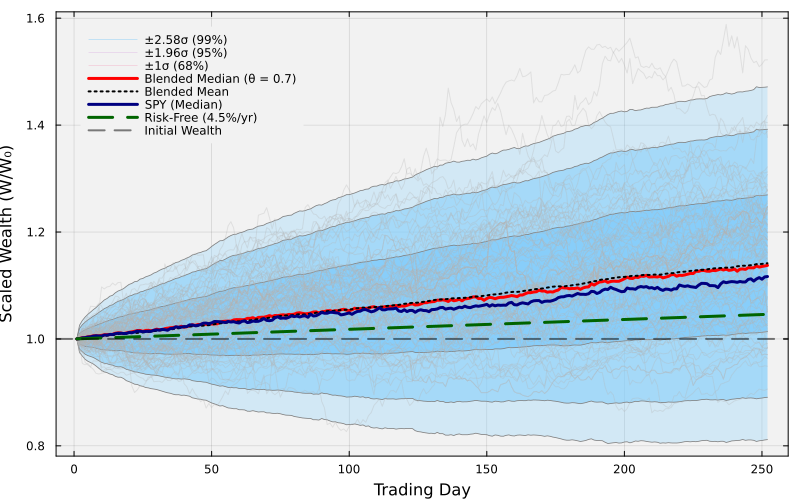

In [14]:
let
    # --- Step 1: Randomly sample paths for the spaghetti overlay ---
    Random.seed!(2027);
    sample_idx = rand(1:scenario.n_paths, 100);
    N = length(my_tickers);

    # --- Step 2: Blended wealth matrix: θ in tangent risky + (1-θ) in risk-free ---
    # W(t, p) = Σ_k shares_k · P(p, t, k)  +  (1-θ) · B₀ · exp(g_f · t · Δt)
    #   shares_k = θ · B₀ · w_k / P(p, 1, k)   (risky shares bought at t=1)
    #   scaled wealth = W(t, p) / B₀
    wealth_all = zeros(scenario.n_steps, scenario.n_paths);
    for pidx ∈ 1:scenario.n_paths
        shares = [(θ * B₀ * tangent_weights[k]) / scenario.price_paths[pidx, 1, k] for k in 1:N];
        for t ∈ 1:scenario.n_steps
            risky = sum(shares[k] * scenario.price_paths[pidx, t, k] for k in 1:N);
            cash  = (1 - θ) * B₀ * exp(g_f * t * Δt);
            wealth_all[t, pidx] = (risky + cash) / B₀;
        end
    end

    # --- Step 3: Cross-path mean / median / std of the blended wealth ---
    median_trajectory = [median(wealth_all[t, :]) for t ∈ 1:scenario.n_steps];
    mean_trajectory   = [mean(wealth_all[t, :])   for t ∈ 1:scenario.n_steps];
    std_trajectory    = [std(wealth_all[t, :])    for t ∈ 1:scenario.n_steps];

    # --- Step 4: Benchmarks, scaled by B₀ ---
    # SPY buy-and-hold (100% equity market): W_SPY(t, p) / B₀ = market_paths[p, t] / market_paths[p, 1]
    spy_scaled = zeros(scenario.n_steps, scenario.n_paths);
    for pidx ∈ 1:scenario.n_paths
        p0 = scenario.market_paths[pidx, 1];
        for t ∈ 1:scenario.n_steps
            spy_scaled[t, pidx] = scenario.market_paths[pidx, t] / p0;
        end
    end
    spy_median = [median(spy_scaled[t, :]) for t ∈ 1:scenario.n_steps];

    # Risk-free baseline (deterministic, path-independent): exp(g_f · t · Δt)
    rf_trajectory = [exp(g_f * t * Δt) for t ∈ 1:scenario.n_steps];

    # --- Step 5: Sampled paths for the spaghetti overlay ---
    wealth_sample = wealth_all[:, sample_idx];

    # --- Step 6: Plot ---
    # Gaussian quantile multipliers: 1.00σ ≈ 68%, 1.96σ ≈ 95%, 2.58σ ≈ 99% (two-sided).
    days = 1:scenario.n_steps;

    # Nested confidence ribbons (99% outermost, 95% middle, 68% innermost).
    # Plot outer first so inner bands paint over.
    p = plot(days, mean_trajectory;
        ribbon = 2.58 .* std_trajectory,
        fillalpha = 0.30, fillcolor = :lightskyblue,
        lw = 0, label = "±2.58σ (99%)",
        xlabel = "Trading Day",
        ylabel = "Scaled Wealth (W/W₀)",
        fontsize = 18,
        size = (800, 500));
    plot!(p, days, mean_trajectory .+ 2.58 .* std_trajectory; lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory .- 2.58 .* std_trajectory; lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory;
        ribbon = 1.96 .* std_trajectory,
        fillalpha = 0.60, fillcolor = :lightskyblue,
        lw = 0, label = "±1.96σ (95%)");
    plot!(p, days, mean_trajectory .+ 1.96 .* std_trajectory; lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory .- 1.96 .* std_trajectory; lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory;
        ribbon = 1.00 .* std_trajectory,
        fillalpha = 0.95, fillcolor = :lightskyblue,
        lw = 0, label = "±1σ (68%)");
    plot!(p, days, mean_trajectory .+ 1.00 .* std_trajectory; lw = 0.8, c = :gray50, label = "");
    plot!(p, days, mean_trajectory .- 1.00 .* std_trajectory; lw = 0.8, c = :gray50, label = "");

    # Spaghetti overlay of sampled blended paths
    plot!(p, days, wealth_sample;
        lw = 1, c = :gray69, alpha = 0.30, label = "");

    # Median / mean of the blended portfolio
    plot!(p, days, median_trajectory;
        lw = 3, c = :red, label = "Blended Median (θ = $(θ))");
    plot!(p, days, mean_trajectory;
        lw = 2, ls = :dot, c = :black, label = "Blended Mean");

    # SPY median overlay (100% equity benchmark)
    plot!(p, days, spy_median;
        lw = 3, c = :navy, label = "SPY (Median)");

    # Risk-free baseline
    plot!(p, days, rf_trajectory;
        lw = 3, ls = :dash, c = :darkgreen,
        label = "Risk-Free ($(round(g_f*100, digits=1))%/yr)");

    # Break-even reference
    hline!(p, [1.0];
        lw = 2, ls = :dash, c = :black, alpha = 0.5, label = "Initial Wealth");

    plot!(p, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent,
        legend = :topleft);
    display(p)
end;

Finally we summarize the forward simulation results in a scorecard table and save the tangent allocation to disk.

In [15]:
let
    T_years  = n_steps / 252;
    rf_terminal = B₀ * exp(g_f * T_years);
    θ_rf_terminal = (1 - θ) * rf_terminal;

    # Blended final wealth = risky part + risk-free part
    blended_final = result_tangent.final_wealth .+ θ_rf_terminal;

    rows = [
        summary_row("Tangent (θ=$(θ))", blended_final),
        summary_row("Market (SPY)",     result_mkt.final_wealth),
        (Portfolio = "Risk-Free ($(round(g_f*100, digits=1))%)",
         Median_W = round(rf_terminal, digits=0),
         VaR_5 = round(rf_terminal, digits=0),
         Sharpe = "---"),
    ];
    df = DataFrame(rows);

    println("Forward simulation summary ($(n_paths) paths, $(n_steps) days, θ=$(θ)):");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));
end

Forward simulation summary (500 paths, 252 days, θ=0.7):
 ------------------ ---------- ---------- --------
         Portfolio   Median_W      VaR_5   Sharpe 
            String    Float64    Float64      Any 
 ------------------ ---------- ---------- --------
   Tangent (θ=0.7)   113758.0    94500.0    1.076
      Market (SPY)   111674.0    81961.0     0.59
  Risk-Free (4.5%)   104603.0   104603.0      ---
 ------------------ ---------- ---------- --------


In [16]:
let
    # --- Save tangent-specific artifact (full CML metadata) ---
    save_path = joinpath(_PATH_TO_DATA, "tangent-allocation.jld2");
    save_results(save_path, Dict(
        "my_tickers"       => my_tickers,
        "tangent_weights"  => tangent_weights,
        "sharpe_ratio"     => sharpe_result["sharpe_ratio"],
        "expected_return"  => sharpe_result["expected_return"],
        "volatility"       => sharpe_result["volatility"],
        "g_f"              => g_f,
        "r_f"              => g_f,              # backward-compatible alias
        "theta"            => θ,
        "cash_fraction"    => cash_fraction,
        "sim_estimates"    => sim_estimates,
        "sigma_market"     => σ_m,
    ));
    println("Saved tangent allocation to: $(save_path)");

    # --- Also save minvar-allocation.jld2 with tangent weights for downstream S2/S3/S4 ---
    # Downstream sessions expect this file. The allocation_weights are the
    # tangent-portfolio risky weights (sum to 1); cash_fraction is held separately.
    minvar_path = joinpath(_PATH_TO_DATA, "minvar-allocation.jld2");
    save_results(minvar_path, Dict(
        "my_tickers"         => my_tickers,
        "allocation_weights" => tangent_weights,
        "sim_estimates"      => sim_estimates,
        "sigma_market"       => σ_m,
        "R_target"           => sharpe_result["expected_return"],
        "g_f"                => g_f,
        "r_f"                => g_f,
        "cash_fraction"      => cash_fraction,
    ));
    println("Saved downstream artifact to: $(minvar_path)");
    println("  cash_fraction = $(round(cash_fraction*100, digits=1))%");
end

Saved tangent allocation to: /Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-1/data/tangent-allocation.jld2
Saved downstream artifact to: /Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-1/data/minvar-allocation.jld2
  cash_fraction = 30.0%


___
## Summary
This example computed the maximum Sharpe ratio (tangent) portfolio via SOCP, constructed the Capital Allocation Line from the risk-free rate through the tangent portfolio, and forward-simulated a blended allocation across synthetic futures to compare against passive benchmarks.

> __Key Takeaways:__
>
> * __The tangent portfolio maximizes risk-adjusted growth:__ By solving a second-order cone program we identify the single risky portfolio with the highest Sharpe ratio. This portfolio sits at the point where the CAL is tangent to the efficient frontier.
> * __The CAL dominates the risky-only frontier:__ Any investor who can lend or borrow at the risk-free rate achieves a better risk-return trade-off on the CAL than on the frontier alone. The blending fraction controls total risk without changing the risky allocation.
> * __Synthetic forward simulation grounds the theory in distributional outcomes:__ The hybrid JumpHMM construction generates realistic futures that preserve heavy tails and regime structure. Comparing blended wealth against SPY and the risk-free baseline shows whether the Sharpe advantage survives over a one-year horizon.

The saved parameter file is used by downstream notebooks for preference weight computation and covariance construction.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.
___